#  Pertemuan 3: Linear Regression & Polynomial Regression

**Nama:** Muhammad Rizal Haris  
**NIM:** 105841103223  
**Kelas:** 5A Applied Machine Learning  
**Tanggal:** 14 Maret 2026

> Pastikan semua cell sudah dijalankan dan tidak ada error.

# 1. Tujuan Praktikum

Tujuan dari praktikum ini adalah untuk memahami bagaimana model regresi digunakan dalam memprediksi nilai numerik berdasarkan data yang tersedia. Pada praktikum ini mahasiswa mempelajari cara membangun model Linear Regression sederhana, Multiple Linear Regression, serta Polynomial Regression untuk menangkap pola hubungan yang lebih kompleks pada data.

Selain itu, praktikum ini juga bertujuan untuk melatih kemampuan dalam melakukan eksplorasi data, membagi dataset menjadi data latih dan data uji, serta mengevaluasi performa model menggunakan beberapa metrik evaluasi seperti MAE, RMSE, dan R².

> Dengan melakukan percobaan ini diharapkan mahasiswa dapat memahami bagaimana sebuah model machine learning bekerja dalam mempelajari hubungan antara variabel input dan variabel target.

# 2. Dataset yang Digunakan

Dataset yang digunakan pada praktikum ini adalah Student Performance Dataset yang berisi berbagai faktor yang mempengaruhi performa akademik siswa.

Beberapa variabel yang digunakan antara lain:

**Hours_Studied	 :** jumlah jam belajar siswa

**Attendance :** tingkat kehadiran siswa

**Sleep_Hours :** durasi tidur siswa

**Exam_Score :** nilai ujian siswa
> Variabel exam_score digunakan sebagai target yang akan diprediksi oleh model regresi.

# 3. Langkah Kerja

Langkah-langkah yang dilakukan pada praktikum ini adalah sebagai berikut:

- Mengimpor library yang diperlukan untuk pengolahan data dan pembuatan model.
- Memuat dataset ke dalam lingkungan Python menggunakan library Pandas.
- Melakukan eksplorasi data untuk melihat struktur dataset.
- Membuat model Simple Linear Regression menggunakan satu variabel.
- Membuat model Multiple Linear Regression menggunakan beberapa variabel.
- Membangun model Polynomial Regression untuk melihat kemungkinan hubungan non-linear.
- Mengevaluasi performa model menggunakan metrik evaluasi.
- Membandingkan hasil dari masing-masing model regresi.

# IMPORT LIBRARY
**Kode di bawah digunakan untuk memanggil beberapa library yang dibutuhkan dalam praktikum ini.**
- pandas digunakan untuk membaca dan mengelola data dalam bentuk tabel (dataframe).
- numpy digunakan untuk membantu proses perhitungan numerik yang dibutuhkan dalam analisis data.
- matplotlib digunakan untuk membuat visualisasi agar pola dan hubungan data lebih mudah dipahami.
- train_test_split digunakan untuk membagi dataset menjadi data latih dan data uji.
- LinearRegression digunakan untuk membangun model regresi linear.
- PolynomialFeatures digunakan untuk mengubah fitur menjadi bentuk polynomial.
- mean_absolute_error, mean_squared_error, dan r2_score digunakan untuk mengevaluasi kinerja model.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Memuat Dataset
- pd.read_csv("StudentPerformanceFactors.csv") digunakan untuk membaca file dataset berformat CSV ke dalam program.
- Dataset yang dimuat berisi informasi terkait berbagai faktor yang mempengaruhi performa siswa.
- Data yang sudah dibaca kemudian disimpan ke dalam variabel df untuk memudahkan proses analisis.
- df.head() digunakan untuk menampilkan beberapa baris awal dari dataset.
- Langkah ini dilakukan untuk memastikan data sudah terbaca dengan benar.

- Selain itu, tampilan awal ini membantu memahami struktur data, nama kolom, serta contoh isi dari dataset.

In [17]:
df = pd.read_csv("StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


# Melihat Informasi Dataset
- df.info() digunakan untuk menampilkan gambaran umum dataset seperti jumlah data, nama kolom, serta tipe data pada setiap variabel.
- Informasi ini membantu mengetahui apakah terdapat data yang kosong atau tipe data yang kurang sesuai.
- df.describe() digunakan untuk menampilkan ringkasan statistik dari kolom numerik.
- Ringkasan tersebut meliputi nilai rata-rata, nilai minimum, nilai maksimum, serta standar deviasi.
- Dengan melihat hasil ini, kita bisa memahami karakteristik dasar dari data sebelum melakukan pemodelan.

In [18]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


# Visualisasi Data
- Visualisasi ini digunakan untuk melihat hubungan antara jam belajar dan nilai ujian siswa.
- Grafik yang digunakan berupa scatter plot yang menampilkan hubungan dua variabel dalam bentuk titik-titik.
- Sumbu horizontal menunjukkan jumlah jam belajar, sedangkan sumbu vertikal menunjukkan nilai ujian.
- Dengan grafik ini, kita dapat melihat apakah terdapat hubungan antara kedua variabel tersebut.
- Jika titik-titik membentuk pola tertentu, maka hal itu bisa menjadi indikasi adanya hubungan antara jam belajar dan nilai ujian.
- Visualisasi ini membantu memahami kecenderungan data secara lebih intuitif dibandingkan hanya melihat angka.

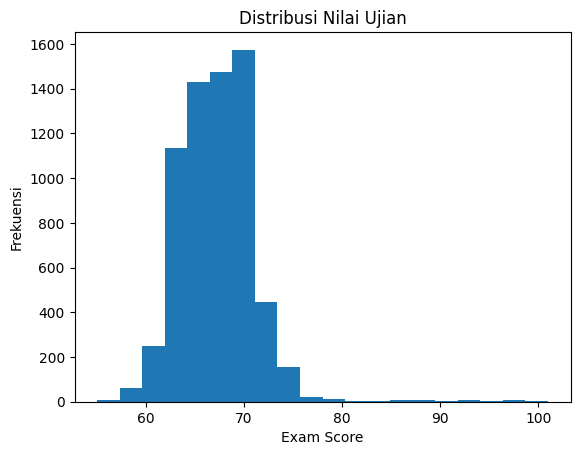

In [19]:
plt.hist(df["Exam_Score"], bins=20)
plt.title("Distribusi Nilai Ujian")
plt.xlabel("Exam Score")
plt.ylabel("Frekuensi")
plt.show()

# Simple Linear Regression
- Model linear regression sederhana digunakan untuk memprediksi nilai ujian berdasarkan satu variabel, yaitu jam belajar.
- Variabel input (fitur) menggunakan kolom Hours_Studied.
- Variabel target menggunakan kolom Exam_Score yang akan diprediksi.
- Dataset dibagi menjadi data latih dan data uji menggunakan train_test_split.
- Pembagian ini bertujuan agar model dapat belajar dari sebagian data dan diuji pada data yang belum pernah dilihat.
- Model dibangun menggunakan LinearRegression dari library scikit-learn.
- Proses pelatihan dilakukan dengan fungsi fit() agar model memahami pola hubungan antara variabel.
- Setelah model dilatih, dilakukan prediksi menggunakan fungsi predict() pada data uji.
- Scatter plot digunakan untuk melihat hubungan antara jam belajar dan nilai ujian.
- Grafik ini membantu menunjukkan apakah terdapat hubungan antara kedua variabel tersebut.
- Jika pola titik cenderung naik, maka dapat diindikasikan adanya hubungan positif antara jam belajar dan nilai ujian.

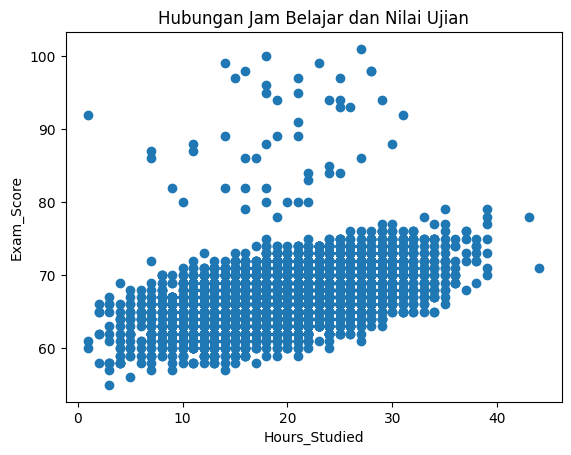

In [20]:
plt.scatter(df["Hours_Studied"], df["Exam_Score"])
plt.xlabel("Hours_Studied")
plt.ylabel("Exam_Score")
plt.title("Hubungan Jam Belajar dan Nilai Ujian")
plt.show()

# Evaluasi Model
- Evaluasi model dilakukan untuk mengetahui seberapa baik model regresi dalam melakukan prediksi.
- MAE (Mean Absolute Error) digunakan untuk mengukur rata-rata selisih absolut antara nilai prediksi dan nilai sebenarnya.
- Semakin kecil nilai MAE, maka semakin baik performa model.
- RMSE (Root Mean Squared Error) digunakan untuk mengukur kesalahan prediksi dengan penalti lebih besar pada error yang tinggi.
- Nilai RMSE yang kecil menunjukkan bahwa model memiliki tingkat kesalahan yang rendah.
- R2 (Coefficient of Determination) digunakan untuk melihat seberapa baik model menjelaskan variasi data.
- Nilai R2 yang mendekati 1 menunjukkan bahwa model memiliki kemampuan prediksi yang baik.
- Proses dimulai dengan menentukan fitur (X) dan target (y) dari dataset.
- Dataset kemudian dibagi menjadi data latih dan data uji menggunakan train_test_split.
- Model LinearRegression dilatih menggunakan data latih dengan fungsi fit().
- Setelah itu, model digunakan untuk memprediksi data uji dengan fungsi predict().
- Hasil prediksi kemudian dibandingkan dengan data asli untuk menghitung MAE, RMSE, dan R2.
- Nilai evaluasi ini digunakan sebagai dasar untuk menilai kualitas model yang telah dibuat.

In [21]:
fitur = df[["Hours_Studied"]]
target = df["Exam_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    fitur, target, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

prediksi = model.predict(X_test)

In [22]:
mae = mean_absolute_error(y_test, prediksi)
rmse = np.sqrt(mean_squared_error(y_test, prediksi))
r2 = r2_score(y_test, prediksi)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 2.4475687452945643
RMSE: 3.294832513010839
R2: 0.2319868674542106


# Visualisasi Hasil Regresi Linear
Grafik ini menunjukkan garis regresi yang menggambarkan hubungan linear antara waktu belajar dan nilai ujian.

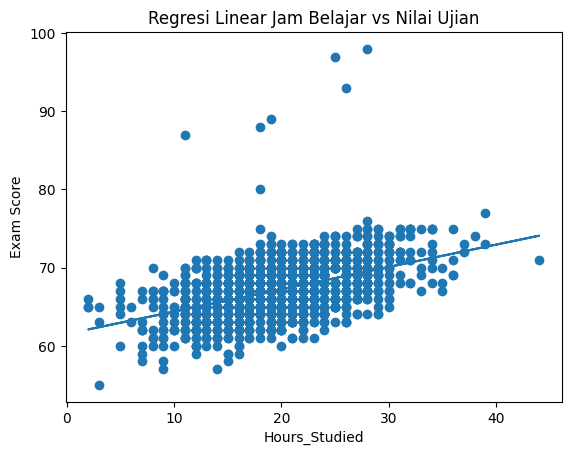

In [23]:
plt.scatter(X_test, y_test)
plt.plot(X_test, prediksi)
plt.xlabel("Hours_Studied")
plt.ylabel("Exam Score")
plt.title("Regresi Linear Jam Belajar vs Nilai Ujian")
plt.show()

# Multiple Linear Regression
- Multiple Linear Regression digunakan untuk memprediksi nilai dengan lebih dari satu variabel input.
- Fitur yang digunakan meliputi Hours_Studied, Attendance, dan Sleep_Hours.
- Dengan beberapa variabel, model dapat menangkap informasi yang lebih lengkap terkait faktor yang mempengaruhi nilai ujian.
- Variabel target tetap menggunakan Exam_Score.
- Dataset dibagi menjadi data latih dan data uji menggunakan train_test_split.
- Model dibangun menggunakan LinearRegression dan dilatih dengan fungsi fit().
- Setelah pelatihan, model digunakan untuk melakukan prediksi dengan fungsi predict().
- Hasil prediksi kemudian dievaluasi menggunakan MAE, RMSE, dan R2.
- Penggunaan lebih dari satu fitur biasanya menghasilkan performa yang lebih baik dibanding regresi sederhana.

In [24]:
fitur = df[["Hours_Studied","Attendance","Sleep_Hours"]]
target = df["Exam_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    fitur, target, test_size=0.2, random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

prediksi_multi = model_multi.predict(X_test)

In [26]:
print("MAE:", mean_absolute_error(y_test, prediksi_multi))
print("RMSE:", np.sqrt(mean_squared_error(y_test, prediksi_multi)))
print("R2:", r2_score(y_test, prediksi_multi))

MAE: 1.4706300773376364
RMSE: 2.412019889780555
R2: 0.5884110279740732


# Polynomial Regression
- Polynomial Regression digunakan ketika hubungan antar variabel tidak sepenuhnya linear.
- Metode ini mengubah fitur menjadi bentuk polynomial, seperti pangkat dua atau lebih.
- Dalam kasus ini digunakan degree = 2 untuk menangkap pola hubungan yang melengkung.
- PolynomialFeatures digunakan untuk membentuk fitur baru dari variabel asli.
- Setelah transformasi, model LinearRegression tetap digunakan untuk proses pelatihan.
- Pendekatan ini memungkinkan model menangkap pola yang lebih kompleks dibanding linear biasa.
- Model kemudian dilatih dan digunakan untuk melakukan prediksi seperti pada regresi sebelumnya.
- Polynomial Regression sering memberikan hasil lebih baik jika data memiliki pola non-linear.

In [27]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

pred_poly = model_poly.predict(X_test_poly)

mae_poly = mean_absolute_error(y_test, pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, pred_poly))
r2_poly = r2_score(y_test, pred_poly)

print("MAE:", mae_poly)
print("RMSE:", rmse_poly)
print("R2:", r2_poly)

MAE: 1.469363398705005
RMSE: 2.4142688798568317
R2: 0.587643131271113
